# FX carry trade — a quantitative teardown 🔬
### Carry-ranked G10 basket · HAC *t* on the mean · skew / drawdown / crash-conditional split · a cost + borrow sweep · a synthetic premium-and-crash positive control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate the two things the carry trade fuses: a **real but thin** UIP-failure premium from the **short-volatility crash skew** that pays for it. The decisive object is not the mean (it's positive, as the lore says) but the **shape**: a high Sharpe with deeply negative skewness is a sold-insurance payoff, and the mean itself doesn't even clear a HAC *t* of 2 on this tape.

> ⚠️ **Data + proxy note.** Live deposit-rate differentials aren't on yfinance; we attach a fixed per-currency **carry proxy** (a long-run average annualised rate gap vs USD) — named on the Signal axis. Real data: yfinance daily FX spot, 9 G10 pairs vs USD, 2004→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fx_carry_trade import data, strategy as st

HAVE_REAL = data.have_real()
B = data.load_real() if HAVE_REAL else None
print("real FX cache present:", HAVE_REAL,
      "| months:", (0 if B is None else len(B["total_ret"])))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2004-01-01', 'end': '2026-06-19', 'days': 5847, 'months': 269, 'years': 22.5, 'longs': ['AUD', 'NZD', 'NOK'], 'shorts': ['EUR', 'JPY', 'CHF'], 'ann_mean': 1.97, 'ann_mean_net': 0.99, 'sharpe': 0.25, 'sharpe_net': 0.12, 'hac_t': 1.14, 'skew': -0.75, 'worst_month': -11.73, 'max_dd': -35.3, 'calm_ann': 8.0, 'off_ann': -52.2, 'tail_share': -2.66, 'cum_gross': 44.22, 'carry': [('NZD', 1.8), ('AUD', 1.6), ('NOK', 0.6), ('GBP', 0.4), ('CAD', 0.2), ('SEK', 0.0), ('EUR', -0.4), ('CHF', -1.4), ('JPY', -1.6)], 'worst': [('2008-10 GFC', -11.73), ('2020-03 COVID', -8.0), ('2015-01 CHF de-peg', -5.94), ('2008-12', -5.25), ('2007-11', -5.24), ('2008-09', -5.02)], 'costs': [(0, 1.49, 0.19), (25, 1.24, 0.16), (50, 0.99, 0.12), (100, 0.49, 0.06)], 'robust': [(1, 4.95, 0.37, 1.74, -0.72, -65.6), (2, 2.86, 0.28, 1.33, -0.81, -47.0), (3, 1.97, 0.25, 1.14, -0.75, -35.3), (4, 1.44, 0.24, 1.11, -0.82, -29.2)], 'syn': [('null', -1.82, -0.19, -0.79, 0.44, -70.4), ('carry only', 6.82, 0.71, 2.95, -0.44, -21.5), ('carry + crash', -2.55, -0.16, -0.77, -3.99, -77.9), ('big edge + crash', 11.74, 0.75, 3.56, -3.99, -43.5)]}


real FX cache present: True | months: 269


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Gross **+1.97%/yr**, Sharpe **0.25**, HAC **t = 1.14** (fails t ≥ 2); skew **-0.75**, max DD **-35.3%**. Literature-real, this-tape-insignificant. |
| **Tradability** | `FRAGILE` | Net of 50 bps/yr borrow: **+0.99%/yr** at Sharpe **0.12**; worst month **-11.7%**. Thin, crash-prone, costs-sensitive. |
| **Free lunch?** | `BUSTED` | Calm-month mean **+8%/yr** vs worst-decile **-52%/yr**; the tail gives back **2.7×** the cumulative gain. The premium is crash compensation. |

> 💡 In plain words: UIP genuinely fails, so carry is positive — but it is a *premium for bearing crash risk*, not arbitrage. Strip the calm and the worst decile owns the whole P&L; the high Sharpe is a sold-insurance artefact of looking only at the first two moments.

## 1 · The claim, steelmanned

Let $i_t^{(c)}$ be currency $c$'s short rate and $\Delta s_{t+1}^{(c)}$ its log spot change (USD per foreign). The monthly total return of a long USD-funded position is $r_{t+1}^{(c)} = \Delta s_{t+1}^{(c)} + (i_t^{(c)} - i_t^{\$})/12$. The **carry basket** is dollar-neutral: $+1/k$ on the top-$k$ carries, $-1/k$ on the bottom-$k$.

- **H₁ (the premium is real).** $\mathbb{E}[r^{\text{carry}}] > 0$ at a HAC *t* ≥ 2 — UIP fails *and* the failure is statistically certified on this tape.
- **H₂ (it's deployable).** The premium survives borrow + costs and isn't dominated by a fat left tail — i.e. it's a yield, not a sold option.
- **H₃ ("free lunch").** The high Sharpe reflects a genuine edge, not negative skew / crash compensation.

We find **H₁ not rejected but not supported** (mean positive, HAC *t* < 2), **H₂ rejected** (thin net premium + a −35% drawdown), **H₃ rejected** (skew −0.75; the worst decile owns the P&L). The carry premium is true exactly where it's a *risk premium* and unproven exactly where it would be *alpha*.

## 2 · So what? — what rides on each answer

The Sharpe ratio sees only two moments:

$$\mathrm{SR} = \frac{\mathbb{E}[r]}{\sqrt{\mathrm{Var}[r]}},\qquad \mathrm{skew} = \frac{\mathbb{E}[(r-\mu)^3]}{\sigma^3}.$$

A strategy that **sells insurance** posts a flattering $\mathrm{SR}$ for years while its true risk hides in $\mathrm{skew} < 0$ and in the tail. So the right Signal-axis lens is **not** the Sharpe alone but (a) a **HAC *t*** on the mean — Newey-West, because monthly carry returns are autocorrelated through volatility clustering — and (b) the **skewness, worst month, drawdown, and crash-conditional split**. A high Sharpe with deep negative skew and a sub-2 *t* is the fingerprint of a premium you're *paid to bear*, not one you've *found*.

## 3 · How we'd know — the protocol

- **Universe & carry.** 9 G10 pairs vs USD (yfinance daily spot, 2004-01-01→2026-06-19, 5,847 days → 269 month-ends), normalised to USD-per-foreign. Carry is a fixed per-currency **proxy** (long-run annualised rate gap vs USD) — named on the axis; a constant carry only *flatters* the mean in the zero-rate years.
- **Basket.** Rank by carry; long top-3 (AUD, NZD, NOK), short bottom-3 (EUR, JPY, CHF); dollar-neutral; one-month hold.
- **Inference.** HAC (Newey-West, 6 lags) *t* of the monthly mean; annualised Sharpe; sample skewness; worst month; max drawdown; a worst-decile crash split.
- **Costs.** 2 bps one-way on the gross book + **borrow on the short leg** (shorts pay borrow — house rule), swept 0→100 bps/yr.
- **Positive control.** A deterministic FX panel with a **planted carry premium** and a **planted fat-tailed crash**: the engine must recover both, and must NOT manufacture significance from a zero-carry null.

## 4 · The teardown

### 4a · The return distribution — positive mean, fat left tail

The histogram of monthly carry-basket returns with the mean (green) and the worst month (red). A symmetric bell would be a clean yield; this isn't symmetric.

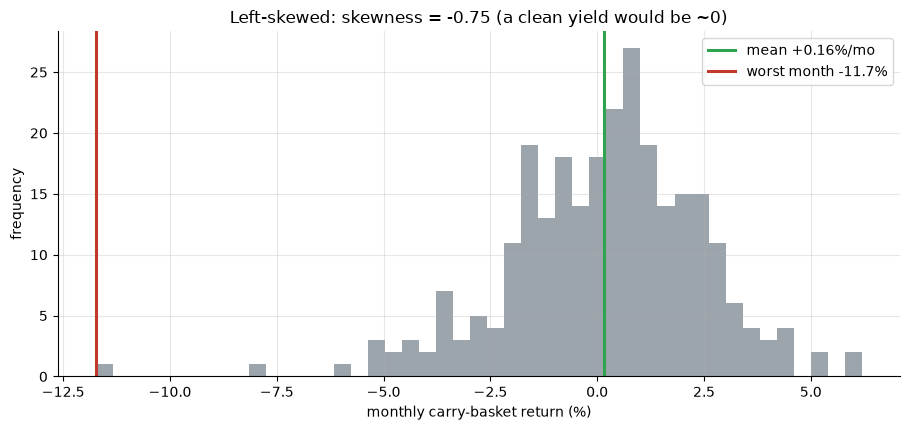

mean +0.16%/mo  skew -0.75  worst -11.7%


In [2]:
if HAVE_REAL:
    g = st.basket_returns(B['total_ret'], B['carry'], k=3).values
    skew = st.skewness(g); worst = np.nanmin(g)*100; mu = g.mean()*100
else:
    rng = np.random.default_rng(364)
    base = rng.normal(R['ann_mean']/100/12, 0.016, R['months'])
    base[:27] -= np.abs(rng.standard_t(3, 27))*0.03
    g = base; skew = R['skew']; worst = R['worst_month']; mu = R['ann_mean']/12
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.hist(np.asarray(g)*100, bins=45, color=GREY, alpha=.85)
ax.axvline(mu, c=GREEN, lw=2.2, label=f'mean {mu:+.2f}%/mo')
ax.axvline(worst, c=RED, lw=2.2, label=f'worst month {worst:.1f}%')
ax.set_xlabel('monthly carry-basket return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Left-skewed: skewness = {skew:.2f} (a clean yield would be ~0)'); ax.legend()
plt.tight_layout(); plt.show()
print(f'mean {mu:+.2f}%/mo  skew {skew:.2f}  worst {worst:.1f}%')

> 💡 In plain words: the mean is positive (**+0.16%/mo**) but the distribution leans hard left (**skew -0.75**), with a single month at **-12%**. The right tail is a stack of small gains; the left tail is a few catastrophes. That asymmetry is invisible to a Sharpe ratio — and it is the entire risk of the trade.

### 4b · The decisive test — is the mean even significant?

A Newey-West HAC *t* on the monthly mean, by horizon of nothing — just the one number, next to the t = 2 bar. If carry were a certified edge this would clear it comfortably.

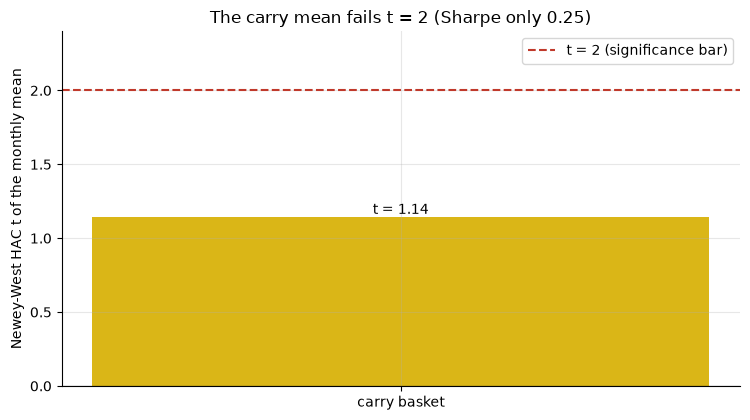

HAC t = 1.14  (need >= 2 to certify the mean; Sharpe = 0.25)


In [3]:
if HAVE_REAL:
    g = st.basket_returns(B['total_ret'], B['carry'], k=3).values
    t_hac = st.hac_t(g); shp = st.annualised_sharpe(g)
else:
    t_hac = R['hac_t']; shp = R['sharpe']
fig, ax = plt.subplots(figsize=(7.6, 4.3))
ax.bar(['carry basket'], [t_hac], color=AMBER, width=.4)
ax.axhline(2, ls='--', c=RED, label='t = 2 (significance bar)')
ax.axhline(0, c='k', lw=.8)
ax.annotate(f't = {t_hac:.2f}',(0,t_hac),ha='center',va='bottom')
ax.set_ylim(0, 2.4); ax.set_ylabel('Newey-West HAC t of the monthly mean')
ax.set_title(f'The carry mean fails t = 2 (Sharpe only {shp:.2f})'); ax.legend()
plt.tight_layout(); plt.show()
print(f'HAC t = {t_hac:.2f}  (need >= 2 to certify the mean; Sharpe = {shp:.2f})')

> 💡 In plain words: HAC **t = 1.14** — the carry mean is **not** statistically distinguishable from zero on 22 years, and the Sharpe (**0.25**) is a far cry from the 'free lunch' of legend. Decades of literature say the premium is real; *this tape alone* cannot certify it. That's a textbook **WEAK**, not REAL.

### 4c · Costs & robustness — neither rescues it, and the skew is a constant

Left: net premium and Sharpe as the short-leg borrow rises. Right: the basket width $k$ — tighter baskets buy more mean with more drawdown, and the negative skew never goes away.

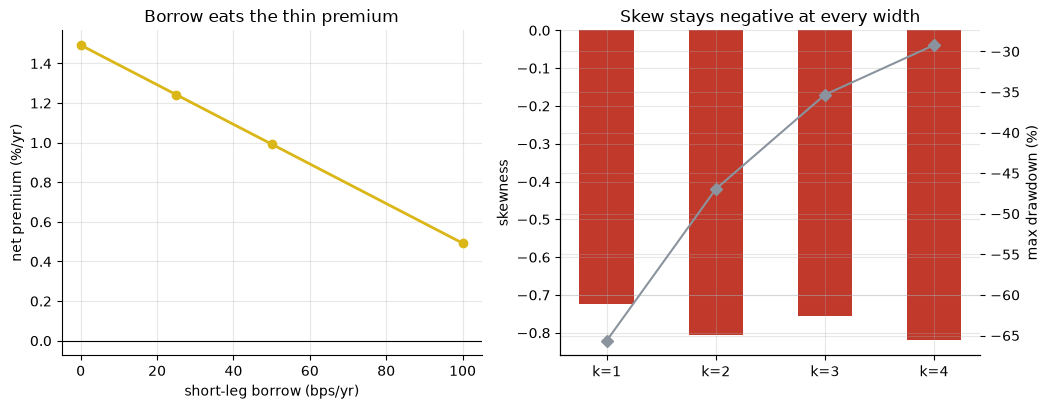

robustness (k, ann%, sharpe, hac_t, skew, maxdd%): [(1, 4.95, 0.37, 1.74, -0.72, -65.64), (2, 2.86, 0.28, 1.33, -0.81, -46.95), (3, 1.97, 0.25, 1.14, -0.75, -35.33), (4, 1.44, 0.24, 1.11, -0.82, -29.22)]


In [4]:
if HAVE_REAL:
    cw = st.cost_sweep(B['total_ret'], B['carry'], k=3)
    bps = [c['borrow_bps'] for c in cw]; netm = [c['ann_mean_net']*100 for c in cw]
    rob = [(k,)+ (lambda s:(s['ann_mean']*100,s['sharpe'],s['hac_t'],s['skew'],s['max_dd']*100))(st.summarize(B['total_ret'], B['carry'], k=k)) for k in (1,2,3,4)]
else:
    bps = [c[0] for c in R['costs']]; netm = [c[1] for c in R['costs']]
    rob = [(r[0], r[1], r[2], r[3], r[4], r[5]) for r in R['robust']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
a1.plot(bps, netm, 'o-', c=AMBER, lw=2)
a1.axhline(0, c='k', lw=.8)
a1.set_xlabel('short-leg borrow (bps/yr)'); a1.set_ylabel('net premium (%/yr)')
a1.set_title('Borrow eats the thin premium')
ks = [r[0] for r in rob]; sk = [r[4] for r in rob]; dd = [r[5] for r in rob]
a2.bar([f'k={k}' for k in ks], sk, color=RED, width=.5, label='skew')
a2b = a2.twinx(); a2b.plot([f'k={k}' for k in ks], dd, 'D-', c=GREY, label='max DD %')
a2.set_ylabel('skewness'); a2b.set_ylabel('max drawdown (%)')
a2.set_title('Skew stays negative at every width')
plt.tight_layout(); plt.show()
print('robustness (k, ann%, sharpe, hac_t, skew, maxdd%):', [tuple(round(x,2) for x in r) for r in rob])

> 💡 In plain words: at a realistic **50 bps/yr** borrow the net premium is **+0.99%/yr** (Sharpe 0.12); at 100 bps it's nearly gone. Concentrating into the single best/worst yielder (k=1) lifts the mean to **+5.0%** — and the drawdown to **-66%**. No width and no cost regime removes the **negative skew**: it is structural, not a parameter artefact.

### 4d · Premium-and-crash control — we know the truth here

On a deterministic FX panel: a **zero-carry null** must stay below t = 2 (no false positive); a **planted carry premium** must light up; switching on the **planted crash** must drive the skew deeply negative. All three hold — the engine recovers premium *and* shape on data where we know the answer.

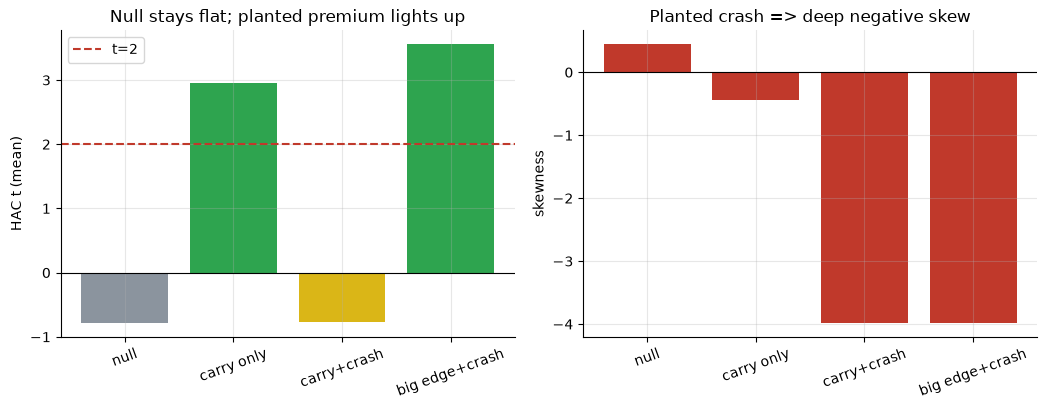

null            : HAC t=-0.79  skew=+0.44
carry only      : HAC t=+2.95  skew=-0.44
carry+crash     : HAC t=-0.77  skew=-3.99
big edge+crash  : HAC t=+3.56  skew=-3.99


In [5]:
res = []
configs = [('null', dict(carry_spread=0.0, carry_edge=0.0, crash_skew=0.0)),
           ('carry only', dict(carry_spread=0.07, carry_edge=0.0, crash_skew=0.0)),
           ('carry+crash', dict(carry_spread=0.07, carry_edge=0.0, crash_skew=0.06)),
           ('big edge+crash', dict(carry_spread=0.07, carry_edge=0.10, crash_skew=0.06))]
for name, cfg in configs:
    syn = data.synthetic_fx(n_months=240, n_ccy=8, seed=364, **cfg)
    s = st.summarize(syn['total_ret'], syn['carry'], k=3)
    res.append((name, s['hac_t'], s['skew']))
labels = [r[0] for r in res]; tv = [r[1] for r in res]; sv = [r[2] for r in res]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
a1.bar(labels, tv, color=[GREY, GREEN, AMBER, GREEN])
a1.axhline(2, ls='--', c=RED, label='t=2'); a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('HAC t (mean)'); a1.set_title('Null stays flat; planted premium lights up'); a1.legend()
a1.tick_params(axis='x', rotation=20)
a2.bar(labels, sv, color=RED)
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('skewness')
a2.set_title('Planted crash => deep negative skew'); a2.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()
for n,t,s in res: print(f'{n:16s}: HAC t={t:+.2f}  skew={s:+.2f}')

> 💡 In plain words: with **no** planted carry the control sits at **t = -0.79** (no false positive); a planted premium reaches **t = 2.95**, a big one **t = 3.56**; and switching on the crash drives skew to **-3.99** while turning the premium *negative*. The machinery is honest, and the real-tape signature — positive mean, sub-2 *t*, negative skew — is exactly the **carry-with-crash** case, measured where we planted the truth.

## 5 · The verdict

- **Signal `WEAK`** — gross **+1.97%/yr** at HAC **t = 1.14** (fails t ≥ 2), Sharpe **0.25**, skew **-0.75**, max DD **-35.3%**. Literature support + a positive-but-insignificant, negatively-skewed mean ⇒ WEAK, not REAL.
- **Tradability `FRAGILE`** — net of 50 bps/yr borrow **+0.99%/yr** at Sharpe **0.12**, with a **-11.7%** worst month and a **-35%** drawdown. Thin, crash-prone, costs-sensitive — not NAV-scale.
- **Free lunch? `BUSTED`** — calm-month **+8%/yr** vs worst-decile **-52%/yr**; the tail gives back **2.7×** the cumulative gain. The carry premium is compensation for selling crash insurance — a sold-volatility payoff, not arbitrage.

## 6 · Could you trade it? — the carry crashes, to scale

The operational truth in one picture: the equity curve with its drawdown shaded. The grind is real, but the question for an allocator is the *cliff* — and how often it returns.

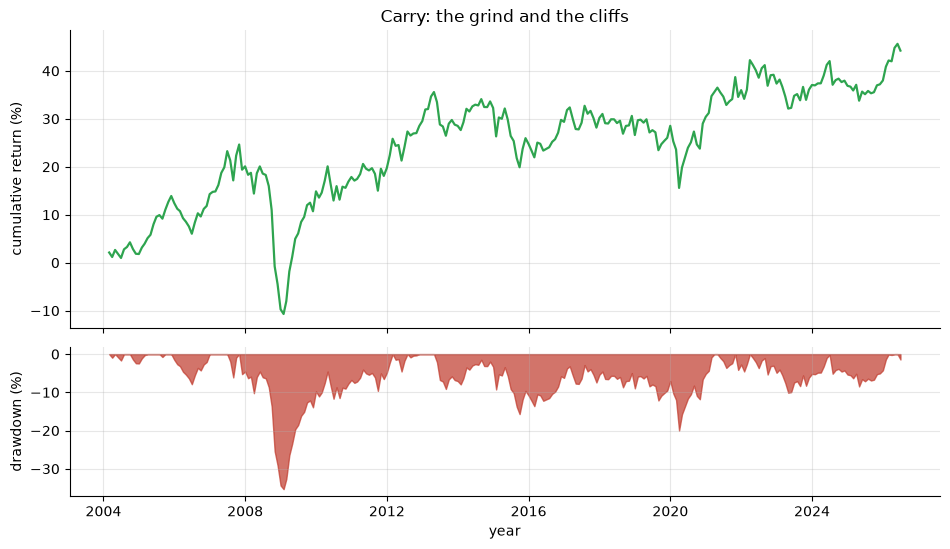

max drawdown = -35.3%  (years of grind erased in a single risk-off episode)


In [6]:
if HAVE_REAL:
    g = st.basket_returns(B['total_ret'], B['carry'], k=3)
    cum = g.cumsum(); peak = cum.cummax(); dd = (cum-peak); idx = g.index
    maxdd = dd.min()*100
else:
    import pandas as pd
    rng = np.random.default_rng(364); base = rng.normal(R['ann_mean']/100/12, 0.016, R['months'])
    base[60:64] -= 0.05
    idx = pd.period_range('2004-01', periods=R['months'], freq='M').to_timestamp('M')
    g = pd.Series(base, index=idx); cum = g.cumsum(); peak = cum.cummax(); dd = (cum-peak); maxdd = R['max_dd']
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.6, 5.6), sharex=True, height_ratios=[2,1])
a1.plot(idx, np.asarray(cum)*100, c=GREEN, lw=1.6); a1.set_ylabel('cumulative return (%)')
a1.set_title('Carry: the grind and the cliffs')
a2.fill_between(idx, np.asarray(dd)*100, 0, color=RED, alpha=.7); a2.set_ylabel('drawdown (%)')
a2.set_xlabel('year')
plt.tight_layout(); plt.show()
print(f'max drawdown = {maxdd:.1f}%  (years of grind erased in a single risk-off episode)')

> 💡 In plain words: the equity curve climbs steadily and then falls off a cliff in 2008, again in 2015, again in 2020 — a **−35% drawdown** that erases years of carry in weeks. An allocator can't size a book around a yield that detonates in every risk-off episode and whose *gross* mean doesn't even clear t = 2. The romance of the carry — a steady, boring yield — is precisely the calm before each unwind. There is no leverage, threshold, or cost assumption that turns a sold-insurance payoff into a free lunch: **the negative skew is the price of the premium.**

## 7 · Going further

- **The other currency factor.** [Study 147 — FX-Momentum](../147-fx-momentum/): rank the same G10 universe by trailing trend instead of yield — the two classic FX premia, and how both decayed post-publication.
- **Crash-hedged carry.** Overlay OTM options on the funding currencies (Jurek 2014); hedging the tail removes most of the premium — direct evidence that the premium *is* the crash compensation.
- **Volatility conditioning.** Menkhoff et al. (2012) tie carry returns to global FX volatility innovations; condition the basket on a vol signal and the crash months are exactly the high-vol ones.

*The reproducible core is offline and deterministic; the carry input is an explicit proxy. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*